In [1]:
!pip install sacrebleu==2.3.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 4.9 MB/s eta 0:00:00


In [2]:

import torch.nn as nn
import torch
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import math
import sacrebleu


PAD_TOKEN = '<pad>'
SOS_TOKEN = '<sos>'
EOS_TOKEN = '<eos>'
UNK_TOKEN = '<unk>'

class Vocab:
    def __init__(self, counter, min_freq=2):
        self.itos = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
        self.stoi = {token: i for i, token in enumerate(self.itos)}

        for token, freq in counter.items():
            if freq >= min_freq:
                self.stoi[token] = len(self.itos)
                self.itos.append(token)

    def __len__(self):
        return len(self.itos)

    def encode(self, tokens):
        return [self.stoi.get(token, self.stoi[UNK_TOKEN]) for token in tokens]

    def decode(self, indices):
        return [self.itos[i] for i in indices]


def build_vocab(file_path, min_freq=2):

    counter = Counter()

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            tokens = line.strip().split()
            counter.update(tokens)
    return Vocab(counter, min_freq=min_freq)

class TranslationDataset(Dataset):
    def __init__(self, src_path, trg_path, vocab_src, vocab_trg):
        with open(src_path, 'r', encoding='utf-8') as f:
            self.src_data = f.readlines()
        with open(trg_path, 'r', encoding='utf-8') as f:
            self.trg_data = f.readlines()

        self.vocab_src = vocab_src
        self.vocab_trg = vocab_trg

    def __len__(self):
        return len(self.src_data)

    def __getitem__(self, idx):
        src_tokens = self.src_data[idx].strip().split()
        trg_tokens = self.trg_data[idx].strip().split()

        src_encoded = self.vocab_src.encode(src_tokens)
        trg_encoded = self.vocab_trg.encode(trg_tokens)
        trg_encoded = [self.vocab_trg.stoi[SOS_TOKEN]] + trg_encoded + [self.vocab_trg.stoi[EOS_TOKEN]]

        return torch.tensor(src_encoded), torch.tensor(trg_encoded)


def collate_fn(batch):

    src_batch, trg_batch = zip(*batch)
    src_batch = pad_sequence(src_batch, padding_value=0, batch_first=True)
    trg_batch = pad_sequence(trg_batch, padding_value=0, batch_first=True)

    return src_batch, trg_batch

In [6]:
vocab_de = build_vocab('/kaggle/input/datasets/ivanbrazil/data-bhw2/data 2/train.de-en.de', min_freq=3)
vocab_en = build_vocab('/kaggle/input/datasets/ivanbrazil/data-bhw2/data 2/train.de-en.en', min_freq=3)


In [7]:
print(len(vocab_de))
print(len(vocab_en))

38465
26257


In [8]:
with open('/kaggle/input/datasets/ivanbrazil/data-bhw2/data 2/train.de-en.de', 'r') as f:
    src_lines = f.readlines()
with open('/kaggle/input/datasets/ivanbrazil/data-bhw2/data 2/train.de-en.en', 'r') as f:
    trg_lines = f.readlines()

src_lens = [len(l.strip().split()) for l in src_lines]
trg_lens = [len(l.strip().split()) for l in trg_lines]

print(f'Кол-во предложений: {len(src_lines)}')
print(f'DE: mean={sum(src_lens)/len(src_lens):.1f}, median={sorted(src_lens)[len(src_lens)//2]}, max={max(src_lens)}')
print(f'EN: mean={sum(trg_lens)/len(trg_lens):.1f}, median={sorted(trg_lens)[len(trg_lens)//2]}, max={max(trg_lens)}')
print(f'Vocab DE: {len(vocab_de)}, Vocab EN: {len(vocab_en)}')


unk_de = sum(1 for l in src_lines for t in l.strip().split() if t not in vocab_de.stoi)
unk_en = sum(1 for l in trg_lines for t in l.strip().split() if t not in vocab_en.stoi)
total_de = sum(src_lens)
total_en = sum(trg_lens)
print(f'UNK DE: {unk_de}/{total_de} ({unk_de/total_de*100:.2f}%)')
print(f'UNK EN: {unk_en}/{total_en} ({unk_en/total_en*100:.2f}%)')


Кол-во предложений: 195915
DE: mean=18.3, median=15, max=80
EN: mean=19.7, median=16, max=80
Vocab DE: 38465, Vocab EN: 26257
UNK DE: 101939/3589782 (2.84%)
UNK EN: 37859/3854425 (0.98%)


In [9]:
with open('/kaggle/input/datasets/ivanbrazil/data-bhw2/data 2/train.de-en.de', 'r') as f:
    lengths = [len(line.strip().split()) for line in f]

print(f'Max: {max(lengths)}')
print(f'Mean: {sum(lengths)/len(lengths)}')
print(f'95th perc: {sorted(lengths)[int(len(lengths)*0.95)]}')
print(f'99th perc: {sorted(lengths)[int(len(lengths)*0.99)]}')


Max: 80
Mean: 18.323160554322026
95th perc: 42
99th perc: 58


In [12]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


In [13]:
def create_masks(src, trg):
    src_padding_mask = (src == 0)
    trg_padding_mask = (trg == 0)


    trg_len = trg.size(1)
    trg_mask = torch.triu(torch.ones(trg_len, trg_len), diagonal=1).bool().to(trg.device)

    return src_padding_mask, trg_padding_mask, trg_mask


In [14]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, d_ff, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoding = PositionalEncoding(d_model, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True
        )
        self.layers = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.d_model = d_model

    def forward(self, src, src_mask=None, src_padding_mask=None):
        x = self.embedding(src) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.layers(x, mask=src_mask, src_key_padding_mask=src_padding_mask)

        return x

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, trg, src_padding_mask=None,
                trg_mask=None, trg_padding_mask=None):

        encoder_output = self.encoder(src, src_padding_mask=src_padding_mask)

        output = self.decoder(
            trg, encoder_output,
            trg_mask=trg_mask,
            trg_padding_mask=trg_padding_mask,
            memory_padding_mask=src_padding_mask
        )

        return output


class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, d_ff, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)

        self.pos_encoding = PositionalEncoding(d_model, dropout=dropout)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True
        )
        self.layers = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.d_model = d_model

    def forward(self, trg, encoder_output, trg_mask=None,
                trg_padding_mask=None, memory_padding_mask=None):
        x = self.embedding(trg) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.layers(
            x, encoder_output,
            tgt_mask=trg_mask,
            tgt_key_padding_mask=trg_padding_mask,
            memory_key_padding_mask=memory_padding_mask
        )
        return self.fc_out(x)


In [15]:
def calc_val_loss(model, val_loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src, trg in val_loader:
            src, trg = src.to(device), trg.to(device)
            trg_input = trg[:, :-1]
            trg_output = trg[:, 1:]
            src_padding_mask, trg_padding_mask, trg_mask = create_masks(src, trg_input)
            output = model(src, trg_input, src_padding_mask, trg_mask, trg_padding_mask)
            output = output.reshape(-1, output.size(-1))
            trg_output = trg_output.reshape(-1)
            loss = criterion(output, trg_output)
            total_loss += loss.item()
    return total_loss / len(val_loader)

def calc_bleu(model, sources, references, vocab_src, vocab_trg):
    model.eval()
    translations = []
    for src_sentence in sources:
        translation = translate(model, src_sentence, vocab_src, vocab_trg)
        translations.append(translation)
    bleu = sacrebleu.corpus_bleu(translations, [references], tokenize='none', force=True)
    return bleu.score
def translate(model, src_sentence, vocab_src, vocab_trg, max_len=80):
    model.eval()
    tokens = src_sentence.strip().split()
    src = torch.tensor([vocab_src.encode(tokens)]).to(device)
    src_padding_mask = (src == 0)
    with torch.no_grad():
        encoder_output = model.encoder(src, src_padding_mask=src_padding_mask)
    trg_indices = [vocab_trg.stoi[SOS_TOKEN]]
    for _ in range(max_len):
        trg_tensor = torch.tensor([trg_indices]).to(device)
        trg_mask = torch.triu(torch.ones(len(trg_indices), len(trg_indices)),
                              diagonal=1).bool().to(device)
        with torch.no_grad():
            output = model.decoder(trg_tensor, encoder_output,
                                   trg_mask=trg_mask,
                                   memory_padding_mask=src_padding_mask)
        next_token = output[0, -1].argmax().item()
        trg_indices.append(next_token)
        if next_token == vocab_trg.stoi[EOS_TOKEN]:
            break
    result = vocab_trg.decode(trg_indices[1:-1])
    return ' '.join(result)


In [16]:
d_model = 512
nhead = 8
d_ff = 512
num_layers = 3
dropout = 0.1
batch_size = 128
num_epochs = 25
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

encoder = Encoder(len(vocab_de), d_model, nhead, d_ff, num_layers, dropout)
decoder = Decoder(len(vocab_en), d_model, nhead, d_ff, num_layers, dropout)
decoder.fc_out.weight = decoder.embedding.weight
model = Seq2Seq(encoder, decoder)

for p in model.parameters():
    if p.dim() > 1:
        nn.init.xavier_uniform_(p)

model = model.to(device)

train_dataset = TranslationDataset(
    '/kaggle/input/datasets/ivanbrazil/data-bhw2/data 2/train.de-en.de',
    '/kaggle/input/datasets/ivanbrazil/data-bhw2/data 2/train.de-en.en',
    vocab_de, vocab_en
)
val_dataset = TranslationDataset(
    '/kaggle/input/datasets/ivanbrazil/data-bhw2/data 2/val.de-en.de',
    '/kaggle/input/datasets/ivanbrazil/data-bhw2/data 2/val.de-en.en',
    vocab_de, vocab_en
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

with open('/kaggle/input/datasets/ivanbrazil/data-bhw2/data 2/val.de-en.en', 'r') as f:
    val_references = [line.strip() for line in f]
with open('/kaggle/input/datasets/ivanbrazil/data-bhw2/data 2/val.de-en.de', 'r') as f:
    val_sources = [line.strip() for line in f]

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)
criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 1/25
Train: 5.652445567347192
Val: 4.69132274389267 
 BLEU: 6.636690735490193
Best: 6.636690735490193
REF: when i was 11 , i remember waking up one morning to the sound of joy in my house .
OUT: when i was been been years ago , i was a first of the first year of the world .

Epoch 2/25
Train: 4.592352779607692
Val: 4.080968618392944 
 BLEU: 15.371507390142812
Best: 15.371507390142812
REF: when i was 11 , i remember waking up one morning to the sound of joy in my house .
OUT: when i was 11 years old , i was a morning from the morning , i was going to be a morning from the morning .

Epoch 3/25
Train: 4.130721997000048
Val: 3.757928818464279 
 BLEU: 21.761419474469204
Best: 21.761419474469204
REF: when i was 11 , i remember waking up one morning to the sound of joy in my house .
OUT: when i was 11 years old , i was a morning from the <unk> joy .

Epoch 4/25
Train: 3.850451262771188
Val: 3.576441705226898 
 BLEU: 24.982482513594636
Best: 24.982482513594636
REF: when i was 11 , i rem

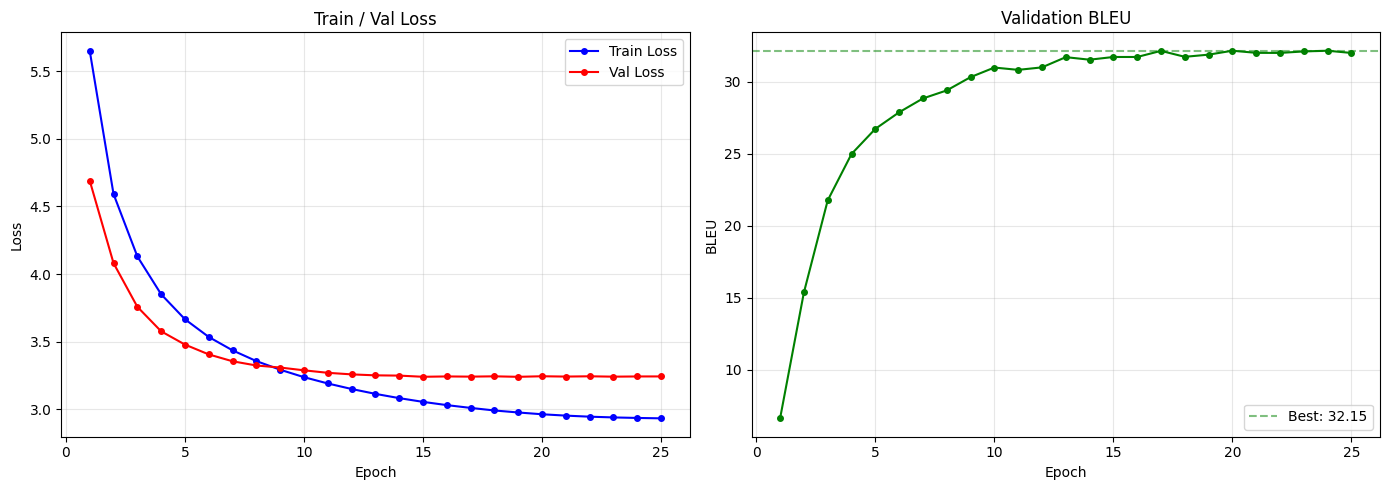

In [15]:
import matplotlib.pyplot as plt
train_losses = []
val_losses = []
bleu_scores = []
best_bleu = 0
scaler = torch.amp.GradScaler('cuda')
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for src, trg in train_loader:
        src, trg = src.to(device), trg.to(device)
        trg_input = trg[:, :-1]
        trg_output = trg[:, 1:]
        src_padding_mask, trg_padding_mask, trg_mask = create_masks(src, trg_input)
        optimizer.zero_grad()
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            output = model(src, trg_input, src_padding_mask, trg_mask, trg_padding_mask)
            output = output.reshape(-1, output.size(-1))
            trg_output = trg_output.reshape(-1)
            loss = criterion(output, trg_output)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    val_loss = calc_val_loss(model, val_loader, criterion)
    bleu = calc_bleu(model, val_sources, val_references, vocab_de, vocab_en)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    bleu_scores.append(bleu)
    scheduler.step()

    if bleu > best_bleu:
        best_bleu = bleu
        torch.save(model.state_dict(), 'best_model.pt')

    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'Train: {train_loss}')
    print(f'Val: {val_loss:} ')
    print(f' BLEU: {bleu:}')
    print(f'Best: {best_bleu}')
    torch.save(model.state_dict(), f'checkpoint_epoch{epoch+1}.pt')
    example_translation = translate(model, val_sources[0], vocab_de, vocab_en)
    print(f'REF: {val_references[0]}')
    print(f'OUT: {example_translation}\n')

model.load_state_dict(torch.load('best_model.pt'))
print(f'Best model is loaded (with BLEU = {best_bleu})')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs = list(range(1, len(train_losses) + 1))
ax1.plot(epochs, train_losses, 'b-o', label='Train Loss', markersize=4)
ax1.plot(epochs, val_losses, 'r-o', label='Val Loss', markersize=4)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Train / Val Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(epochs, bleu_scores, 'g-o', markersize=4)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('BLEU'); ax2.set_title('Validation BLEU')
ax2.axhline(y=best_bleu, color='g', linestyle='--', alpha=0.5, label=f'Best: {best_bleu:.2f}')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:
top3 = sorted(range(len(bleu_scores)), key=lambda i: bleu_scores[i], reverse=True)[:3]
for e in top3:
    print(f'Epoch {e+1}: BLEU {bleu_scores[e]}')

вставил тут из коллаба, но эти веса удалились просто, просто уже никак их не восстановишь, надо заново запускать

In [21]:
paths = [
    '/content/checkpoint_epoch20.pt',
    '/content/checkpoint_epoch24.pt',
    '/content/checkpoint_epoch17.pt',
]

avg_state = None
for path in paths:
    state = torch.load(path, map_location=device)
    if avg_state is None:
        avg_state = {k: v.float() for k, v in state.items()}
    else:
        for k in avg_state:
            avg_state[k] += state[k].float()
for k in avg_state:
    avg_state[k] /= 3

model.load_state_dict(avg_state)

def postprocess(text):
    text = text.replace('<unk>', '')
    words = text.split()
    clean = []
    seen_trigrams = set()
    for w in words:
        clean.append(w)
        if len(clean) >= 3:
            trigram = (clean[-3], clean[-2], clean[-1])
            if trigram in seen_trigrams:
                clean.pop()
            else:
                seen_trigrams.add(trigram)
    return ' '.join(clean).strip()


predictions = []
for src in val_sources:
    predictions.append(postprocess(translate(model, src, vocab_de, vocab_en)))
bleu = sacrebleu.corpus_bleu(predictions, [val_references], tokenize='none', force=True)
print(f'BLEU: {bleu.score}')


BLEU: 30.548811889895486


In [18]:
model.load_state_dict(torch.load('/content/checkpoint_epoch20.pt', map_location=device))

predictions = []
for src in val_sources:
    predictions.append(postprocess(translate(model, src, vocab_de, vocab_en)))
bleu = sacrebleu.corpus_bleu(predictions, [val_references], tokenize='none', force=True)
print(f'BLEU: {bleu.score}')


BLEU: 31.792909862660007


In [22]:
# model.load_state_dict(torch.load('/content/checkpoint_epoch20.pt', map_location=device))
with open('/content/test.txt', 'r') as f:
    test_lines = f.readlines()
with open('test1.de-en.en', 'w') as f:
    for line in test_lines:
        f.write(translate(model, line, vocab_de, vocab_en) + '\n')
print("Готово")


Готово


In [28]:
def beam_translate(model, sentence, vocab_src, vocab_trg, beam_size=3, max_len=80):
    model.eval()


    words = sentence.strip().split()
    ids = vocab_src.encode(words)
    src = torch.tensor([ids]).to(device)
    src_mask = (src == 0)


    with torch.no_grad():
        memory = model.encoder(src, src_padding_mask=src_mask)

    SOS = vocab_trg.stoi[SOS_TOKEN]
    EOS = vocab_trg.stoi[EOS_TOKEN]

    beams = [([SOS], 0.0)]

    for step in range(max_len):
        new_beams = []
        for tokens, score in beams:
            if tokens[-1] == EOS:
                new_beams.append((tokens, score))
                continue

            trg = torch.tensor([tokens]).to(device)
            mask = torch.triu(torch.ones(len(tokens), len(tokens)), diagonal=1).bool()
            mask = mask.to(device)

            with torch.no_grad():
                out = model.decoder(trg, memory, trg_mask=mask, memory_padding_mask=src_mask)
            probs = torch.log_softmax(out[0, -1], dim=-1)
            top_scores, top_ids = probs.topk(beam_size)
            for i in range(beam_size):
                new_tokens = tokens + [top_ids[i].item()]
                new_score = score + top_scores[i].item()
                new_beams.append((new_tokens, new_score))


        new_beams.sort(key=lambda x: x[1], reverse=True)
        beams = new_beams[:beam_size]
        if all(b[0][-1] == EOS for b in beams):
            break

    best_tokens = beams[0][0]
    clean = [t for t in best_tokens if t != SOS and t != EOS]
    return ' '.join(vocab_trg.decode(clean))


In [29]:
model.load_state_dict(torch.load('/content/checkpoint_epoch20.pt', map_location=device))

predictions = []
for src in val_sources:
    predictions.append(beam_translate(model, src, vocab_de, vocab_en, beam_size=3))
bleu = sacrebleu.corpus_bleu(predictions, [val_references], tokenize='none', force=True)
print(f'BLEU: {bleu.score}')


BLEU: 32.51460054124229


In [ ]:
with open('test1.de-en.en', 'w') as f:
    for line in test_lines:
        f.write(beam_translate(model, line.strip(), vocab_de, vocab_en, beam_size=2) + '\n')


Немного меняю настройки но не хочу удалять предыдущую модель чтобы остался график

UPD: не успел

In [ ]:
d_model = 512
nhead = 8
d_ff = 2048
num_layers = 4
dropout = 0.1
batch_size = 128
num_epochs = 25
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

encoder = Encoder(len(vocab_de), d_model, nhead, d_ff, num_layers, dropout)
decoder = Decoder(len(vocab_en), d_model, nhead, d_ff, num_layers, dropout)
decoder.fc_out.weight = decoder.embedding.weight
model = Seq2Seq(encoder, decoder)

for p in model.parameters():
    if p.dim() > 1:
        nn.init.xavier_uniform_(p)

model = model.to(device)

train_dataset = TranslationDataset(
    '/kaggle/input/datasets/ivanbrazil/data-bhw2/data 2/train.de-en.de',
    '/kaggle/input/datasets/ivanbrazil/data-bhw2/data 2/train.de-en.en',
    vocab_de, vocab_en
)
val_dataset = TranslationDataset(
    '/kaggle/input/datasets/ivanbrazil/data-bhw2/data 2/val.de-en.de',
    '/kaggle/input/datasets/ivanbrazil/data-bhw2/data 2/val.de-en.en',
    vocab_de, vocab_en
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

with open('/kaggle/input/datasets/ivanbrazil/data-bhw2/data 2/val.de-en.en', 'r') as f:
    val_references = [line.strip() for line in f]
with open('/kaggle/input/datasets/ivanbrazil/data-bhw2/data 2/val.de-en.de', 'r') as f:
    val_sources = [line.strip() for line in f]

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)
criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

import matplotlib.pyplot as plt
train_losses = []
val_losses = []
bleu_scores = []
best_bleu = 0
scaler = torch.amp.GradScaler('cuda')

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for src, trg in train_loader:
        src, trg = src.to(device), trg.to(device)
        trg_input = trg[:, :-1]
        trg_output = trg[:, 1:]
        src_padding_mask, trg_padding_mask, trg_mask = create_masks(src, trg_input)
        optimizer.zero_grad()
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            output = model(src, trg_input, src_padding_mask, trg_mask, trg_padding_mask)
            output = output.reshape(-1, output.size(-1))
            trg_output = trg_output.reshape(-1)
            loss = criterion(output, trg_output)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    val_loss = calc_val_loss(model, val_loader, criterion)
    bleu = calc_bleu(model, val_sources, val_references, vocab_de, vocab_en)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    bleu_scores.append(bleu)
    scheduler.step()

    if bleu > best_bleu:
        best_bleu = bleu
        torch.save(model.state_dict(), 'best_model.pt')

    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'Train: {train_loss}')
    print(f'Val: {val_loss:} ')
    print(f' BLEU: {bleu:}')
    print(f'Best: {best_bleu}')
    torch.save(model.state_dict(), f'checkpoint_epoch{epoch+1}.pt')
    example_translation = translate(model, val_sources[0], vocab_de, vocab_en)
    print(f'REF: {val_references[0]}')
    print(f'OUT: {example_translation}\n')

model.load_state_dict(torch.load('best_model.pt'))
print(f'Best model is loaded (with BLEU = {best_bleu})')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs = list(range(1, len(train_losses) + 1))
ax1.plot(epochs, train_losses, 'b-o', label='Train Loss', markersize=4)
ax1.plot(epochs, val_losses, 'r-o', label='Val Loss', markersize=4)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Train / Val Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(epochs, bleu_scores, 'g-o', markersize=4)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('BLEU'); ax2.set_title('Validation BLEU')
ax2.axhline(y=best_bleu, color='g', linestyle='--', alpha=0.5, label=f'Best: {best_bleu:.2f}')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 1/25
Train: 5.619406427611407
Val: 4.637738525867462 
 BLEU: 7.6345398362443095
Best: 7.6345398362443095
REF: when i was 11 , i remember waking up one morning to the sound of joy in my house .
OUT: when i was years years , i was a year of the last year of the united states .

Epoch 2/25
Train: 4.527508920660835
Val: 4.001330733299255 
 BLEU: 17.153530023352506
Best: 17.153530023352506
REF: when i was 11 , i remember waking up one morning to the sound of joy in my house .
OUT: when i was 11 years old , i was a day of the early passion of the age of the <unk> .

Epoch 3/25
Train: 4.049066644801882
Val: 3.695636600255966 
 BLEU: 22.015546459672592
Best: 22.015546459672592
REF: when i was 11 , i remember waking up one morning to the sound of joy in my house .
OUT: when i was 11 years old , i was a day of the feeling of the feeling of the passion .

Epoch 4/25
Train: 3.7672550566129477
Val: 3.5189934074878693 
 BLEU: 25.5724050828474
Best: 25.5724050828474
REF: when i was 11 , i remem

In [ ]:
top3 = sorted(range(len(bleu_scores)), key=lambda i: bleu_scores[i], reverse=True)[:3]
for e in top3:
    print(f'Epoch {e+1}: BLEU {bleu_scores[e]}')

In [ ]:
model.load_state_dict(torch.load('/content/checkpoint_epoch20.pt', map_location=device))


predictions = []
for src in val_sources:
    predictions.append(beam_translate(model, src, vocab_de, vocab_en, beam_size=3))
bleu = sacrebleu.corpus_bleu(predictions, [val_references], tokenize='none', force=True)
print(f'BLEU: {bleu.score}')


with open('/kaggle/input/datasets/ivanbrazil/data-bhw2/data 2/test1.de-en.de', 'r') as f:
    test_lines = f.readlines()

with open('test1.de-en.en', 'w') as f:
    for line in tqdm(test_lines):
        f.write(beam_translate(model, line.strip(), vocab_de, vocab_en, beam_size=2) + '\n')

print('Готово')
